In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import os
from scipy.optimize import curve_fit

import scienceplots
plt.style.use(['science', 'ieee'])
plt.rcParams['figure.dpi'] = 300
from PythonAnalysis import *


In [2]:
FTMethod = "DFT"
kappa = 20
FrameTension="IsotropicFrameTension"
InitialConfiguration = "FromFlat"
i1 = 0
i2 = 10
N_k = 10

In [4]:
Simulation = "OnlyMembrane"
EPS = "no"; VFF="no"; KPKL_str=""
N_r = 15
q_values = []
Y_values = []
for r in range (1,N_r+1):
    f1 = 150
    q  = np.genfromtxt(f"/lustre/astro/semygind/Data/MembraneInclusion/{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/{KPKL_str}/rep{r}/AdriaAnalysis/qvector.ana",
                       skip_header=f1)
    q = np.mean(q[:,1:],axis=0)
    q_values.append(q)
    hqn = np.genfromtxt(f"/lustre/astro/semygind/Data/MembraneInclusion/{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/{KPKL_str}/rep{r}/AdriaAnalysis/hqvector.ana",
                        skip_header=f1)
    hqn = np.mean(hqn[:,1:],axis=0)
    Y_values.append(hqn)

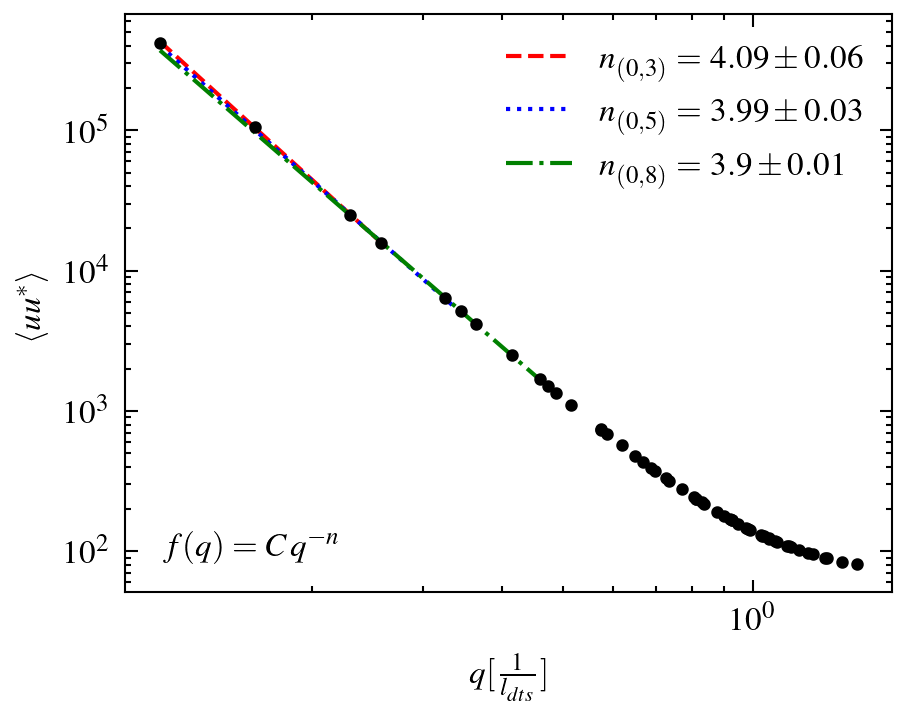

In [6]:
i1 = 0
i2 = [3,5,8]


mean_q = np.mean(q_values,axis=0)
#print("mean_q=",np.shape(mean_q))
mean_Y = np.mean(Y_values,axis=0)
#print("mean_Y=",np.shape(mean_Y))
values = np.transpose(np.vstack([mean_q, Y_values]))   # shape: (N_r + 1, N_q)
error_Y = bootstrap_point_errors(np.transpose(Y_values),N=100000)
#print("error_Y=",np.shape(error_Y))
plt.errorbar(mean_q,mean_Y,yerr=error_Y,fmt='.',markersize=4)
for i in i2:
    #error_Y=bootstrap_point_errors(np.transpose(Y_values))
    #mean_fitvalue, error_fitvalue = bootstrap_point_errors(hqn,N=N_bootstrap )
    #par, cov = curve_fit(qn,mean_q[i1:i],mean_Y[i1:i],sigma=error_Y[i1:i])
    par, cov = bootstrap(values[i1:i],error_Y[i1:i],N=100000)
    #par = fit_loglog(mean_q,mean_Y,error_Y)
    X = np.linspace(mean_q[i1],mean_q[i],100)
    Y = qn(X,par[0],par[1])
    plt.plot(X,Y,
             label=rf"$n_{{({i1},{i})}}={np.round(par[1],2)}\pm {np.round(cov[1],2)}$")
    plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.text(
    0.05, 0.05,                     # x, y in axes-fraction coords (bottom-left)
    r'$f(q) = C\,q^{-n}$',
    transform=plt.gca().transAxes,         # so 0-1 refers to axes, not data coords
    verticalalignment='bottom',
    horizontalalignment='left',
)
plt.xlabel(r"$q [\frac{1}{l_{dts}}]$")
plt.ylabel(r"$\langle u u^* \rangle$")
plt.savefig("Plots/IsotropicFrameTension/FromFlat/OnlyMembrane/I/AdriaAnalysisChainFittingTrue.pdf")

0
1
2


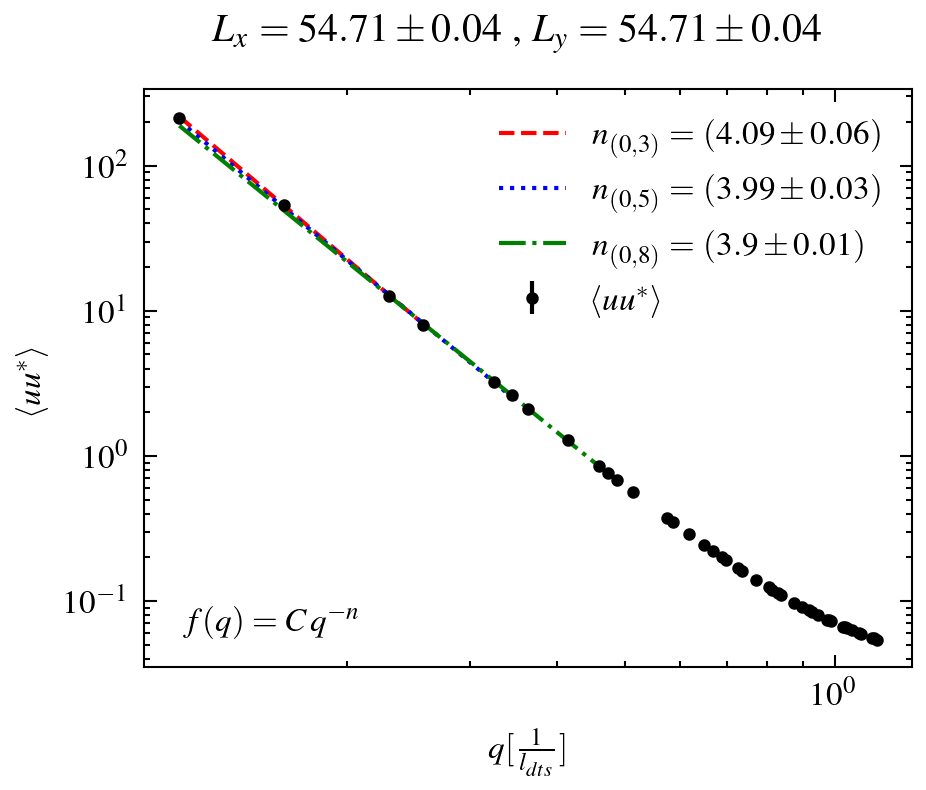

In [3]:
Simulation = "OnlyMembrane"
#Simulation = "OnlyVectorField"
UndulationSpectrum(InitialConfiguration=InitialConfiguration,plot_func="I",N_bootstrap=100000,i1=0,i2=5,
                   FrameTension=FrameTension,Simulation=Simulation,fit_func=True,FTMethod=FTMethod)